# 1. Load dữ liệu

In [125]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## 1.1. Đọc dữ liệu items

In [126]:
items_lf = pl.scan_parquet("../../raw_data/items.parquet")

items_lf.collect().schema

Schema([('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('category_l1', String),
        ('category_l2', String),
        ('category_l3', String),
        ('category', String),
        ('brand', String),
        ('manufacturer', String),
        ('description', String),
        ('sale_status', Int32),
        ('size', String)])

In [127]:
items_lf.head().collect()

item_id,price,category_l1,category_l2,category_l3,category,brand,manufacturer,description,sale_status,size
str,"decimal[38,4]",str,str,str,str,str,str,str,i32,str
"""0008040000046""",115000.0000,"""Đồ chơi & Sách""","""1Y+""","""Học tập và phát triển tư duy""","""Siêu nhân, robot""","""WinWinToys""","""Không xác định""","""Robo Luồn thun Winwintoys có h…",0,"""Không xác định"""
"""0502020000004""",99000.0000,"""Babycare""","""Bình sữa, phụ kiện""","""Núm ty""","""Núm ty Dr Brown""","""Dr.Brown's""","""Không xác định""","""Không xác định""",0,"""Không xác định"""
"""0007010000886""",102000.0000,"""Babycare""","""Bình sữa, phụ kiện""","""Núm ty""","""Núm ty Pigeon""","""Pigeon""","""Không xác định""","""Với hơn 60 năm qua, trải qua r…",0,"""Không xác định"""
"""0502020340030""",228000.0000,"""Babycare""","""Bình sữa, phụ kiện""","""Phụ kiện bình sữa""","""Bình, túi ủ sữa""","""KUKU""","""Không xác định""","""Bình ủ sữa của KuKu của Đài Lo…",0,"""Không xác định"""
"""0012050000007""",59000.0000,"""Thời trang""","""Cơ cấu hàng cũ""","""Đồ bầu""","""Áo ngực bầu""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Không xác định"""


## 1.2. Đọc dữ liệu transactions_202411-to-202412

In [128]:
trans24_lf = pl.scan_parquet("../../raw_data/transactions-202411-to-202412.parquet")

In [129]:
trans24_lf.collect().schema

Schema([('customer_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('channel', String),
        ('payment', String),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('location', Int32),
        ('quantity', Int32)])

In [130]:
trans24_lf.head().collect()

customer_id,item_id,price,channel,payment,updated_date,location,quantity
i32,str,"decimal[38,4]",str,str,datetime[μs],i32,i32
6680595,"""6033000000053""",169000.0000,"""In-Store""","""VietQR""",2024-12-29 17:37:10.410,181,1
3256247,"""4562000000101""",169000.0000,"""In-Store""","""VietQR""",2024-12-30 18:34:51.117,79,1
8180719,"""3500000000005""",49000.0000,"""In-Store""","""VietQR""",2024-12-22 16:01:47.987,1002,1
2079076,"""3500000000004""",49000.0000,"""In-Store""","""VietQR""",2024-12-16 18:30:58.480,242,1
7311623,"""3460000000009""",49500.0000,"""In-Store""","""VietQR""",2024-12-14 19:41:23.670,972,1


## 1.3. Đọc dữ liệu transactions_2025-12

In [131]:
trans25_lf = pl.scan_parquet("../../raw_data/transactions-2025-12.parquet")

In [132]:
trans25_lf.collect().schema


Schema([('customer_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('channel', String),
        ('payment', String),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('location', Int32),
        ('quantity', Int32)])

In [133]:
trans25_lf.head().collect()

customer_id,item_id,price,channel,payment,updated_date,location,quantity
i32,str,"decimal[38,4]",str,str,datetime[μs],i32,i32
8861340,"""0151000000003""",1625000.0000,"""In-Store""","""Tiền mặt""",2025-12-12 16:44:47.793,385,1
8680587,"""5074000000001""",139000.0000,"""SPE""","""Tiền mặt""",2025-12-01 10:28:50.830,1063,1
8220170,"""5856000000001""",480000.0000,"""SPE""","""Tiền mặt""",2025-12-23 09:20:27.653,416,1
7496264,"""6768000000002""",316200.0000,"""SPE""","""Tiền mặt""",2025-12-23 09:06:39.980,336,3
9170522,"""6904000000002""",840000.0000,"""SPE""","""Không xác định""",2025-12-23 09:24:55.640,601,1


# 2. Gộp dữ liệu giao dịch

In [134]:
transactions_lf = pl.concat([
    trans24_lf,
    trans25_lf
])

print(transactions_lf.select(pl.len()).collect().item())

9835894


# 3. Join với bảng sản phẩm
- Đổi tên cột price trong bảng items.
    - transactions.price: giá tại thời điểm giao dịch
    - items.price: giá niêm yết sản phẩm

In [135]:
items_lf = items_lf.rename({
    "price": "item_price"
})

df_lf = transactions_lf.join(
    items_lf,
    on="item_id",
    how="left"
)

df_lf.collect().schema


Schema([('customer_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('channel', String),
        ('payment', String),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('location', Int32),
        ('quantity', Int32),
        ('item_price', Decimal(precision=38, scale=4)),
        ('category_l1', String),
        ('category_l2', String),
        ('category_l3', String),
        ('category', String),
        ('brand', String),
        ('manufacturer', String),
        ('description', String),
        ('sale_status', Int32),
        ('size', String)])

### - Loại bỏ các cột:
- customer_id, channel, payment, location, branch, manufacturer, description, size

In [136]:
df_lf = df_lf.select([
    "item_id",
    "price",
    "item_price",
    "quantity",
    "updated_date",
    "category_l1",
    "category_l2",
    "category_l3",
    "category",
    "sale_status"
])

df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32
"""6033000000053""",169000.0000,219000.0000,1,2024-12-29 17:37:10.410,"""Thời trang""","""Thời trang bé gái""","""Bộ bé gái""","""Bộ bé gái Animo""",0
"""4562000000101""",169000.0000,199000.0000,1,2024-12-30 18:34:51.117,"""Thời trang""","""Thời trang bé gái""","""Bodysuit bé gái""","""Bodysuit bé gái đùi""",0
"""3500000000005""",49000.0000,79000.0000,1,2024-12-22 16:01:47.987,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3500000000004""",49000.0000,79000.0000,1,2024-12-16 18:30:58.480,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1


# 4. Phát hiện và xử lý Missing Data

In [137]:
# các dòng thiếu dữ liệu quan trọng sẽ bị loại bỏ
df_lf = df_lf.filter(
    pl.col("item_id").is_not_null() &
    pl.col("price").is_not_null() &
    pl.col("quantity").is_not_null() &
    pl.col("updated_date").is_not_null()
)
df_lf.head().collect()


item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32
"""6033000000053""",169000.0000,219000.0000,1,2024-12-29 17:37:10.410,"""Thời trang""","""Thời trang bé gái""","""Bộ bé gái""","""Bộ bé gái Animo""",0
"""4562000000101""",169000.0000,199000.0000,1,2024-12-30 18:34:51.117,"""Thời trang""","""Thời trang bé gái""","""Bodysuit bé gái""","""Bodysuit bé gái đùi""",0
"""3500000000005""",49000.0000,79000.0000,1,2024-12-22 16:01:47.987,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3500000000004""",49000.0000,79000.0000,1,2024-12-16 18:30:58.480,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1


# 5. Lọc sản phẩm không còn bán

In [138]:
df_lf = df_lf.filter(
    pl.col("sale_status") == 1
)
print(df_lf.select(pl.len()).collect().item())



7933245


# 6. Loại bỏ dữ liệu bất thường

In [139]:
df_lf = df_lf.filter(
    (pl.col("price") > 0) &
    (pl.col("quantity") > 0)
)
print(df_lf.select(pl.len()).collect().item())


7933245


# 7. Phát hiện Outlier

In [140]:
stats = df_lf.select([
    pl.col("quantity").quantile(0.25).alias("q1"),
    pl.col("quantity").quantile(0.75).alias("q3")
]).collect()

q1 = stats["q1"][0]
q3 = stats["q3"][0]

iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

In [141]:
# Lọc Outlier
df_lf = df_lf.filter(
    (pl.col("quantity") >= lower) &
    (pl.col("quantity") <= upper)
)
print(df_lf.select(pl.len()).collect().item())

6361424


# 8. Feature Engineering

## 8.1. Tạo revenue: 
Ý nghĩa: Doanh thu của từng giao dịch.

Cách tính
$$revenue = price \times quantity$$

Mục đích
- Đo lường **giá trị doanh thu thực tế** của từng giao dịch.
- Cho phép tính **tổng doanh thu theo ngày** hoặc theo nhóm sản phẩm.

In [142]:
df_lf = df_lf.with_columns(
    (pl.col("price") * pl.col("quantity")).alias("revenue")
)

## 8.2. Tạo date
Ý nghĩa:
- Ngày giao dịch được trích xuất từ cột updated_date.

Mục đích:

- Chuyển dữ liệu từ timestamp (datetime) sang ngày.
- Cho phép aggregate dữ liệu theo ngày.
- Là biến chính để phân tích time-series doanh số.

In [143]:
df_lf = df_lf.with_columns(
    pl.col("updated_date").dt.date().alias("date")
)
df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status,revenue,date
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32,"decimal[38,4]",date
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1,49500.0000,2024-12-14
"""4895000000001""",66000.0000,68000.0000,1,2024-12-30 09:03:10.533,"""Thực phẩm cho bé""","""TP từ sữa (bảo quản lạnh)""","""Váng sữa""","""Zott""",1,66000.0000,2024-12-30
"""0020010000210""",33950.0000,36000.0000,1,2024-12-28 18:37:03.107,"""Vệ sinh""","""Băng vệ sinh""","""Băng vệ sinh sau sinh""","""Băng vệ sinh Diana sau sinh""",1,33950.0000,2024-12-28
"""5420000000003""",29000.0000,29000.0000,1,2024-12-25 16:06:13.813,"""Thực phẩm cho bé""","""Cháo ăn dặm""","""Cháo tươi""","""Cây Thị""",1,29000.0000,2024-12-25
"""2406000000005""",585000.0000,635000.0000,1,2024-12-29 08:54:36.970,"""Sữa""","""Enfa""","""Enfa""","""Enfa Step 2""",1,585000.0000,2024-12-29


## 8.3. Tạo holiday feature
- Xác định ngày lễ:
    - 1: ngày lễ (ngày 24/12 và ngày 31/12)
    - 0: ngày thường

In [ ]:
df_lf = df_lf.with_columns(
    pl.when(
        (pl.col("date").dt.month() == 12) &
        ((pl.col("date").dt.day() == 24) | (pl.col("date").dt.day() == 31))
    )
    .then(1)
    .otherwise(0)
    .alias("is_holiday")
)
df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status,revenue,date,is_holiday
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32,"decimal[38,4]",date,i32
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1,49500.0000,2024-12-14,0
"""4895000000001""",66000.0000,68000.0000,1,2024-12-30 09:03:10.533,"""Thực phẩm cho bé""","""TP từ sữa (bảo quản lạnh)""","""Váng sữa""","""Zott""",1,66000.0000,2024-12-30,0
"""0020010000210""",33950.0000,36000.0000,1,2024-12-28 18:37:03.107,"""Vệ sinh""","""Băng vệ sinh""","""Băng vệ sinh sau sinh""","""Băng vệ sinh Diana sau sinh""",1,33950.0000,2024-12-28,0
"""5420000000003""",29000.0000,29000.0000,1,2024-12-25 16:06:13.813,"""Thực phẩm cho bé""","""Cháo ăn dặm""","""Cháo tươi""","""Cây Thị""",1,29000.0000,2024-12-25,0
"""2406000000005""",585000.0000,635000.0000,1,2024-12-29 08:54:36.970,"""Sữa""","""Enfa""","""Enfa""","""Enfa Step 2""",1,585000.0000,2024-12-29,0


## 8.4. Tạo weekday feature
- Ý nghĩa: weekday biểu diễn thứ trong tuần của ngày giao dịch
- Doanh số thường phụ thuộc vào ngày trong tuần (ví dụ khách hàng thường mua nhiều vào cuối tuần), giúp để kiểm soát là do holiday nó tăng doanh số hay là weekend (ngày cuối tuần) mới là nguyên nhân gây tăng doanh số. Do đó, mục đích:
    - Kiểm tra hiệu ứng ngày trong tuần
    - Tránh nhầm lẫn giữa holiday effect và weekend effect
- Phương thức .dt.weekday() trả về một số nguyên đại diện cho các ngày trong tuần với quy ước:

    - 1: Thứ Hai (Monday)

    - 2: Thứ Ba (Tuesday)

    - 3: Thứ Tư (Wednesday)

    - 4: Thứ Năm (Thursday)

    - 5: Thứ Sáu (Friday)

    - 6: Thứ Bảy (Saturday)

    - 7: Chủ Nhật (Sunday)

In [145]:
df_lf = df_lf.with_columns(
    pl.col("date").dt.weekday().alias("weekday")
)

df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status,revenue,date,is_holiday,weekday
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32,"decimal[38,4]",date,i32,i8
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1,49500.0000,2024-12-14,0,6
"""4895000000001""",66000.0000,68000.0000,1,2024-12-30 09:03:10.533,"""Thực phẩm cho bé""","""TP từ sữa (bảo quản lạnh)""","""Váng sữa""","""Zott""",1,66000.0000,2024-12-30,0,1
"""0020010000210""",33950.0000,36000.0000,1,2024-12-28 18:37:03.107,"""Vệ sinh""","""Băng vệ sinh""","""Băng vệ sinh sau sinh""","""Băng vệ sinh Diana sau sinh""",1,33950.0000,2024-12-28,0,6
"""5420000000003""",29000.0000,29000.0000,1,2024-12-25 16:06:13.813,"""Thực phẩm cho bé""","""Cháo ăn dặm""","""Cháo tươi""","""Cây Thị""",1,29000.0000,2024-12-25,0,3
"""2406000000005""",585000.0000,635000.0000,1,2024-12-29 08:54:36.970,"""Sữa""","""Enfa""","""Enfa""","""Enfa Step 2""",1,585000.0000,2024-12-29,0,7


# 9. Aggregate theo ngày
Dữ liệu giao dịch ban đầu được lưu ở cấp độ transaction (từng giao dịch), nghĩa là một ngày có thể có rất nhiều dòng dữ liệu tương ứng với các sản phẩm khác nhau và các lần mua khác nhau.

Để phục vụ cho bài toán kiểm định ảnh hưởng của ngày lễ đến doanh số, dữ liệu cần được tổng hợp ở cấp độ ngày (daily level). Việc tổng hợp này giúp:

- Xác định tổng số lượng sản phẩm bán ra mỗi ngày
- Xác định tổng doanh thu mỗi ngày
- So sánh doanh số giữa ngày lễ và ngày thường

Nhờ đó, dữ liệu trở nên phù hợp hơn cho các phương pháp trực quan hóa và kiểm định thống kê như:

- So sánh trung bình doanh số giữa holiday vs non-holiday
- Thực hiện các kiểm định như t-test hoặc Mann–Whitney test

In [146]:
daily_sales_lf = df_lf.group_by("date").agg([
    pl.sum("quantity").alias("total_quantity"),
    pl.sum("revenue").alias("total_revenue"),
    pl.first("is_holiday")
])
daily_sales_lf.head().collect()

date,total_quantity,total_revenue,is_holiday
date,i32,"decimal[38,4]",i32
2024-11-02,60386,9952455110.0422,0
2024-11-17,64942,10598091087.5678,0
2024-11-05,55446,9561693827.9336,0
2024-12-08,68396,10953787882.9484,0
2024-12-14,64743,10572269078.5518,0


In [147]:
from scipy.stats import mannwhitneyu, permutation_test
import numpy as np

# 10. Kiểm định với mức độ toàn bộ mặt hàng

## 10.1. Tạo dữ liệu daily cho toàn bộ mặt hàng
- Giữ nguyên preprocessing ở phía trên.
- Ở phần kiểm định này, holiday được gắn lại đúng theo đề bài: chỉ tính **24/12** và **31/12** của **tháng 12**.
- Chỉ dùng các ngày thực sự có mặt trong dữ liệu, không tự chèn thêm các ngày 0 doanh thu ngoài phạm vi quan sát.

In [ ]:
all_products_daily = (
    daily_sales_lf
    .select(["date", "total_quantity", "total_revenue"])
    .with_columns([
        pl.when(
            (pl.col("date").dt.month() == 12) &
            ((pl.col("date").dt.day() == 24) | (pl.col("date").dt.day() == 31))
        )
        .then(1)
        .otherwise(0)
        .alias("is_holiday_analysis"),
        pl.col("date").dt.weekday().alias("weekday")
    ])
    .sort("date")
    .collect()
)

holiday_dates = all_products_daily.filter(
    pl.col("is_holiday_analysis") == 1
)["date"].to_list()

print("Số ngày quan sát:", all_products_daily.height)
print("Các ngày holiday có mặt trong dữ liệu:", holiday_dates)
all_products_daily.head()

Số ngày quan sát: 90
Các ngày holiday có mặt trong dữ liệu: [datetime.date(2024, 12, 24), datetime.date(2025, 12, 24)]


date,total_quantity,total_revenue,is_holiday_analysis,weekday
date,i32,"decimal[38,4]",i32,i8
2024-11-01,53581,9251279169.9179,0,5
2024-11-02,60386,9952455110.0422,0,6
2024-11-03,65995,10869825330.9103,0,7
2024-11-04,56858,9865793712.8943,0,1
2024-11-05,55446,9561693827.9336,0,2


## 10.2. Thống kê mô tả theo nhóm ngày lễ và ngày thường

In [149]:
all_products_daily.group_by("is_holiday_analysis").agg([
    pl.len().alias("n_days"),
    pl.mean("total_quantity").alias("mean_quantity"),
    pl.median("total_quantity").alias("median_quantity"),
    pl.mean("total_revenue").alias("mean_revenue"),
    pl.median("total_revenue").alias("median_revenue"),
    pl.std("total_revenue").alias("std_revenue")
]).sort("is_holiday_analysis")

is_holiday_analysis,n_days,mean_quantity,median_quantity,mean_revenue,median_revenue,std_revenue
i32,u32,f64,f64,f64,f64,f64
0,88,70740.215909,61140.5,1.1981e10,1.0359e10,3.5840e9
1,2,68142.5,68142.5,1.1698e10,1.1698e10,3.7362e9


## 10.3. Chuyển sang pandas để trực quan hóa và kiểm định

In [150]:
all_products_pd = all_products_daily.to_pandas()
all_products_pd["date"] = pd.to_datetime(all_products_pd["date"])
all_products_pd["total_quantity"] = all_products_pd["total_quantity"].astype(float)
all_products_pd["total_revenue"] = all_products_pd["total_revenue"].astype(float)
all_products_pd["holiday_label"] = all_products_pd["is_holiday_analysis"].map({0: "Non-holiday", 1: "Holiday"})
all_products_pd.head()

,date,total_quantity,total_revenue,is_holiday_analysis,weekday,holiday_label
0,2024-11-01,53581.0,9.251279e+09,0,5,Non-holiday
1,2024-11-02,60386.0,9.952455e+09,0,6,Non-holiday
2,2024-11-03,65995.0,1.086983e+10,0,7,Non-holiday
3,2024-11-04,56858.0,9.865794e+09,0,1,Non-holiday
4,2024-11-05,55446.0,9.561694e+09,0,2,Non-holiday


## 10.4. Trực quan hóa

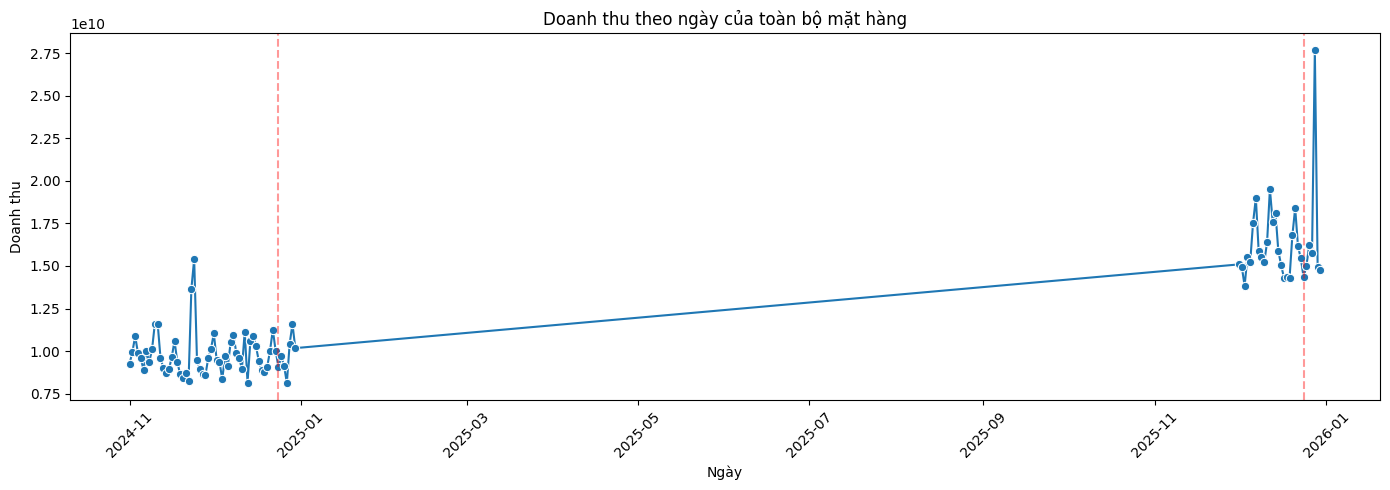

In [151]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=all_products_pd, x="date", y="total_revenue", marker="o")

holiday_dates_pd = all_products_pd.loc[all_products_pd["is_holiday_analysis"] == 1, "date"]
for d in holiday_dates_pd:
    plt.axvline(d, color="red", linestyle="--", alpha=0.4)

plt.title("Doanh thu theo ngày của toàn bộ mặt hàng")
plt.xlabel("Ngày")
plt.ylabel("Doanh thu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Nhận xét 10.4.1**
- Doanh thu toàn bộ mặt hàng biến động mạnh giữa các ngày, nhưng hai ngày holiday quan sát được không tạo thành các đỉnh tách biệt rõ ràng so với nhiều ngày thường có doanh thu cao.
- Điều này gợi ý rằng nếu có holiday effect thì hiệu ứng đó không quá nổi bật ở cấp độ toàn bộ mặt hàng trong tập dữ liệu hiện tại.

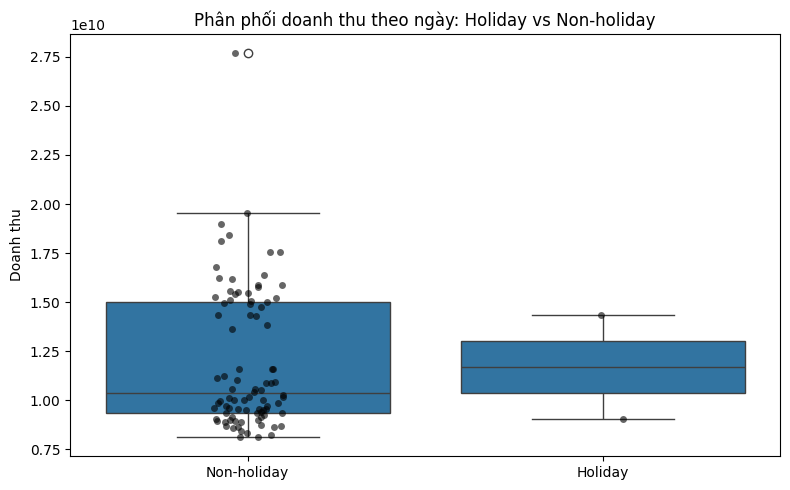

In [152]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=all_products_pd, x="holiday_label", y="total_revenue")
sns.stripplot(data=all_products_pd, x="holiday_label", y="total_revenue", color="black", alpha=0.6)
plt.title("Phân phối doanh thu theo ngày: Holiday vs Non-holiday")
plt.xlabel("")
plt.ylabel("Doanh thu")
plt.tight_layout()
plt.show()

**Nhận xét 10.4.2**
- Hai quan sát holiday nằm trong vùng phân phối của nhóm non-holiday, không tách thành một cụm riêng biệt.
- Số ngày holiday thực tế rất ít nên việc suy luận thống kê cần được diễn giải thận trọng.

## 10.5. Kiểm định giả thuyết cho `total_revenue`
- **H0**: Phân phối doanh thu ngày holiday và ngày thường là như nhau.
- **H1**: Hai phân phối doanh thu khác nhau.

In [153]:
holiday_rev = all_products_pd.loc[
    all_products_pd["is_holiday_analysis"] == 1, "total_revenue"
].to_numpy()
nonholiday_rev = all_products_pd.loc[
    all_products_pd["is_holiday_analysis"] == 0, "total_revenue"
].to_numpy()

n_holiday = len(holiday_rev)
n_nonholiday = len(nonholiday_rev)

print("Số ngày holiday:", n_holiday)
print("Số ngày thường:", n_nonholiday)
print("Doanh thu trung bình ngày holiday:", holiday_rev.mean())
print("Doanh thu trung bình ngày thường:", nonholiday_rev.mean())
print("Doanh thu trung vị ngày holiday:", np.median(holiday_rev))
print("Doanh thu trung vị ngày thường:", np.median(nonholiday_rev))

u_stat, p_value = mannwhitneyu(
    holiday_rev,
    nonholiday_rev,
    alternative="two-sided",
    method="exact"
)
rank_biserial = (2 * u_stat) / (n_holiday * n_nonholiday) - 1

perm_result = permutation_test(
    data=(holiday_rev, nonholiday_rev),
    statistic=lambda x, y: np.mean(x) - np.mean(y),
    permutation_type="independent",
    n_resamples=10000,
    alternative="two-sided",
    random_state=42
)

observed_diff = np.mean(holiday_rev) - np.mean(nonholiday_rev)

print("\nThống kê Mann-Whitney U:", u_stat)
print("Giá trị p của Mann-Whitney:", p_value)
print("Rank-biserial correlation:", rank_biserial)
print("\nChênh lệch trung bình quan sát được (holiday - non-holiday):", observed_diff)
print("Giá trị p của permutation test:", perm_result.pvalue)

Số ngày holiday: 2
Số ngày thường: 88
Doanh thu trung bình ngày holiday: 11697594248.5985
Doanh thu trung bình ngày thường: 11981002099.85833
Doanh thu trung vị ngày holiday: 11697594248.5985
Doanh thu trung vị ngày thường: 10359410959.094349

Thống kê Mann-Whitney U: 78.0
Giá trị p của Mann-Whitney: 0.7990012484394506
Rank-biserial correlation: -0.11363636363636365

Chênh lệch trung bình quan sát được (holiday - non-holiday): -283407851.2598305
Giá trị p của permutation test: 0.9108614232209737


## 10.6. Robustness check với `total_quantity`

In [154]:
holiday_qty = all_products_pd.loc[
    all_products_pd["is_holiday_analysis"] == 1, "total_quantity"
].to_numpy()
nonholiday_qty = all_products_pd.loc[
    all_products_pd["is_holiday_analysis"] == 0, "total_quantity"
].to_numpy()

u_stat_qty, p_value_qty = mannwhitneyu(
    holiday_qty,
    nonholiday_qty,
    alternative="two-sided",
    method="exact"
)
rank_biserial_qty = (2 * u_stat_qty) / (len(holiday_qty) * len(nonholiday_qty)) - 1

perm_result_qty = permutation_test(
    data=(holiday_qty, nonholiday_qty),
    statistic=lambda x, y: np.mean(x) - np.mean(y),
    permutation_type="independent",
    n_resamples=10000,
    alternative="two-sided",
    random_state=42
)

observed_diff_qty = np.mean(holiday_qty) - np.mean(nonholiday_qty)

print("Trung bình quantity ngày holiday:", holiday_qty.mean())
print("Trung bình quantity ngày thường:", nonholiday_qty.mean())
print("Trung vị quantity ngày holiday:", np.median(holiday_qty))
print("Trung vị quantity ngày thường:", np.median(nonholiday_qty))
print("\nThống kê Mann-Whitney U:", u_stat_qty)
print("Giá trị p của Mann-Whitney:", p_value_qty)
print("Rank-biserial correlation:", rank_biserial_qty)
print("\nChênh lệch trung bình quantity (holiday - non-holiday):", observed_diff_qty)
print("Giá trị p của permutation test:", perm_result_qty.pvalue)

Trung bình quantity ngày holiday: 68142.5
Trung bình quantity ngày thường: 70740.21590909091
Trung vị quantity ngày holiday: 68142.5
Trung vị quantity ngày thường: 61140.5

Thống kê Mann-Whitney U: 80.0
Giá trị p của Mann-Whitney: 0.8394506866416979
Rank-biserial correlation: -0.09090909090909094

Chênh lệch trung bình quantity (holiday - non-holiday): -2597.7159090909117
Giá trị p của permutation test: 0.9533083645443196


## 10.7. Kết luận kiểm định

In [155]:
alpha = 0.05

if p_value < alpha:
    print("Kết luận theo Mann-Whitney cho doanh thu: Bác bỏ H0. Có bằng chứng thống kê cho thấy holiday ảnh hưởng đến doanh thu toàn bộ mặt hàng.")
else:
    print("Kết luận theo Mann-Whitney cho doanh thu: Chưa đủ bằng chứng để bác bỏ H0. Chưa thể kết luận holiday ảnh hưởng đến doanh thu toàn bộ mặt hàng.")

if perm_result.pvalue < alpha:
    print("Kết luận theo permutation test cho doanh thu: Bác bỏ H0.")
else:
    print("Kết luận theo permutation test cho doanh thu: Chưa đủ bằng chứng để bác bỏ H0.")

if p_value_qty < alpha:
    print("Kết luận robustness check theo Mann-Whitney cho quantity: Bác bỏ H0.")
else:
    print("Kết luận robustness check theo Mann-Whitney cho quantity: Chưa đủ bằng chứng để bác bỏ H0.")

if perm_result_qty.pvalue < alpha:
    print("Kết luận robustness check theo permutation test cho quantity: Bác bỏ H0.")
else:
    print("Kết luận robustness check theo permutation test cho quantity: Chưa đủ bằng chứng để bác bỏ H0.")

print(f"Lưu ý: chỉ có {n_holiday} ngày holiday thực sự xuất hiện trong dữ liệu, nên power của kiểm định thấp và kết luận cần được diễn giải thận trọng.")

Kết luận theo Mann-Whitney cho doanh thu: Chưa đủ bằng chứng để bác bỏ H0. Chưa thể kết luận holiday ảnh hưởng đến doanh thu toàn bộ mặt hàng.
Kết luận theo permutation test cho doanh thu: Chưa đủ bằng chứng để bác bỏ H0.
Kết luận robustness check theo Mann-Whitney cho quantity: Chưa đủ bằng chứng để bác bỏ H0.
Kết luận robustness check theo permutation test cho quantity: Chưa đủ bằng chứng để bác bỏ H0.
Lưu ý: chỉ có 2 ngày holiday thực sự xuất hiện trong dữ liệu, nên power của kiểm định thấp và kết luận cần được diễn giải thận trọng.
